# Silver Layer Inventory & OBT Readiness Analysis

Notebook phân tích **hiện trạng tầng Silver** trên MinIO — kiểm kê 38 bảng, sample schema từng nhóm, đánh giá khả năng join để chuẩn bị build bảng **`obt_match_360`** (One Big Table) tầng Gold.

**Mục lục**
1. Kết nối MinIO & Kiểm kê tổng quan
2. Nhóm Matches (p03, p09, p24)
3. Nhóm Odds & Market (p03, p22)
4. Nhóm xG & Shot Data (p19/Understat)
5. Nhóm Cầu thủ (p24, p19, p08)
6. Nhóm Dim (Sân, Đội, Wikidata, TheSportsDB)
7. Nhóm Text & Media (p20, p21, p10)
8. Nhóm Thời tiết & Chấn thương (p13, p16)
9. Đánh giá khả năng join → OBT readiness matrix

## 1. Kết nối MinIO & Kiểm kê tổng quan

In [ ]:
# [DÀNH RIÊNG CHO GOOGLE COLAB]
import sys, os
os.environ['MINIO_ENDPOINT'] = 'http://20.41.113.183:9000'
os.environ['MINIO_ACCESS_KEY'] = 'minioadmin'
os.environ['MINIO_SECRET_KEY'] = 'minioadmin123'
if 'SEED_PATH' in os.environ: del os.environ['SEED_PATH']
if 'google.colab' in sys.modules:
    !rm -rf /content/Lab
    !git clone -b ml https://github.com/nbngoc123/Lab.git /content/Lab
    os.chdir('/content/Lab/football-lake')
    sys.path.insert(0, '/content/Lab/football-lake')
    !pip install minio duckdb pandas pyarrow boto3 python-dotenv -q
    print('Setup xong Colab!')


# Run

In [13]:
import io, warnings
import numpy as np
import pandas as pd
import duckdb
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='deep')
plt.rcParams['figure.dpi'] = 110
pd.set_option('display.max_columns', 60)
pd.set_option('display.max_colwidth', 40)

from lake import minio_io as mio

print('✓ Kết nối MinIO OK')
print(f'  Endpoint: {os.environ["MINIO_ENDPOINT"]}')


✓ Kết nối MinIO OK
  Endpoint: http://20.41.113.183:9000


In [14]:
# ── Kiểm kê toàn bộ Silver layer ──────────────────────────────────────────────
rows = []
for key, size in mio.list_keys('silver/'):
    parts = key.split('/')
    if len(parts) >= 3:
        rows.append({
            'table_path': '/'.join(parts[:3]),
            'group': parts[1],
            'table': parts[2],
            'key': key,
            'size_bytes': size,
            'is_parquet': key.endswith('.parquet')
        })

inv = pd.DataFrame(rows)
summary = (inv[inv['is_parquet']]
    .groupby('table_path')
    .agg(n_files=('key', 'count'),
         total_size_kb=('size_bytes', lambda x: x.sum() / 1024))
    .reset_index()
    .sort_values('table_path'))

print(f'Silver tables: {len(summary)}')
print(f'Total size: {summary["total_size_kb"].sum():.0f} KB '
      f'({summary["total_size_kb"].sum()/1024:.1f} MB)')
display(summary.style.format({'total_size_kb': '{:.0f}'}))


Silver tables: 38
Total size: 37101 KB (36.2 MB)


,table_path,n_files,total_size_kb
0,silver/betting/odds_h2h,3,39
1,silver/betting/odds_spreads,3,27
2,silver/betting/odds_totals,3,29
3,silver/dim/fdo_competitions,2,24
4,silver/dim/om_venue_weather,3,2514
5,silver/dim/pr_club_injury_summary,3,9
6,silver/dim/pr_injury_type_frequency,3,7
7,silver/dim/tsdb_media,1,12
8,silver/dim/tsdb_player_former_teams,1,4
9,silver/dim/tsdb_players,1,68


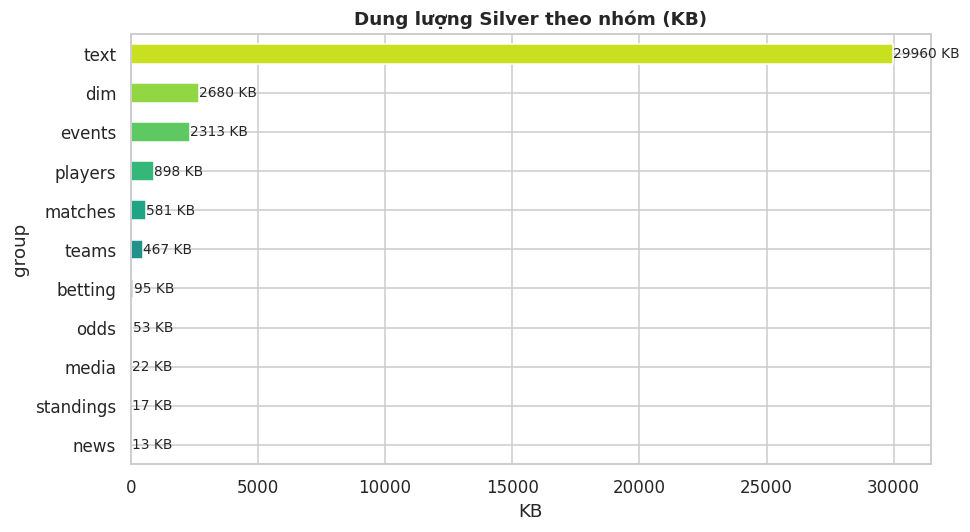

In [15]:
# ── Biểu đồ: size theo nhóm ───────────────────────────────────────────────────
summary['group'] = summary['table_path'].str.split('/').str[1]
group_size = summary.groupby('group')['total_size_kb'].sum().sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9, 5))
colors = sns.color_palette('viridis', len(group_size))
group_size.plot(kind='barh', ax=ax, color=colors, edgecolor='white')
ax.set_title('Dung lượng Silver theo nhóm (KB)', fontweight='bold')
ax.set_xlabel('KB')
for i, (idx, val) in enumerate(group_size.items()):
    ax.text(val + 20, i, f'{val:.0f} KB', va='center', fontsize=9)
plt.tight_layout(); plt.show()


## Helper: đọc bảng Silver từ MinIO

In [16]:
def read_silver(prefix, max_files=10):
    """Doc tat ca parquet trong prefix, tra ve DataFrame."""
    dfs = []
    for key, _ in mio.list_keys(prefix + '/'):
        if key.endswith('.parquet'):
            try:
                raw = mio.read_bytes(key)
                dfs.append(pd.read_parquet(io.BytesIO(raw)))
                if len(dfs) >= max_files:
                    break
            except Exception as e:
                print(f'  ! {key}: {e}')
    if not dfs:
        print(f'  ! Khong co data: {prefix}')
        return pd.DataFrame()
    df = pd.concat(dfs, ignore_index=True)
    print(f'[{prefix.split("/")[-1]}] {len(df):,} dong x {len(df.columns)} cot')
    return df


def schema_summary(df, name=''):
    """In schema + null % + sample."""
    if df.empty:
        return
    null_pct = (df.isna().mean() * 100).round(1)
    schema = pd.DataFrame({
        'dtype': df.dtypes,
        'null_%': null_pct,
        'sample': df.iloc[0] if len(df) else None
    })
    print(f'\n{name} — {len(df):,} rows')
    display(schema)


## 2. Nhóm Matches

Các bảng trận đấu là **spine** (xương sống) của OBT — mọi bảng khác sẽ join vào đây.

| Bảng | Nguồn | Mô tả |
|------|-------|-------|
| `fd_matches` | p03 football-data.co.uk | Lịch sử kết quả + odds thô (2020–2026) |
| `af_fixtures` | p24 API-Football | Fixtures EPL 2024 + score + status |
| `af_match_stats` | p24 API-Football | Thống kê sau trận (possession, shots...) |
| `af_match_events` | p24 API-Football | Sự kiện trong trận (goal, card, sub) |
| `af_lineups` | p24 API-Football | Đội hình ra sân |
| `understat_match_xg` | p19 Understat | xG / xGA per trận |


In [17]:
fd = read_silver('silver/matches/fd_matches')
schema_summary(fd, 'fd_matches')
print('\nSeasons:', sorted(fd['season'].unique()) if 'season' in fd.columns else 'N/A')
print('Date range:', fd['match_date'].min(), '→', fd['match_date'].max() if 'match_date' in fd.columns else 'N/A')


[fd_matches] 760 dong x 28 cot

fd_matches — 760 rows


,dtype,null_%,sample
Div,object,0.0,E0
match_date,datetime64[us],0.0,2024-08-16 00:00:00
Time,object,0.0,20:00
home_team,object,0.0,Man United
away_team,object,0.0,Fulham
home_goals,Int64,0.0,1
away_goals,Int64,0.0,0
result,object,0.0,H
HTHG,Int64,0.0,0
HTAG,Int64,0.0,0



Seasons: ['2024-25', '2025-26']
Date range: 2024-08-16 00:00:00 → 2026-05-24 00:00:00


In [18]:
af_fx = read_silver('silver/matches/af_fixtures')
schema_summary(af_fx, 'af_fixtures')


[af_fixtures] 760 dong x 15 cot

af_fixtures — 760 rows


,dtype,null_%,sample
fixture_id,int64,0.0,1208021
date,object,0.0,2024-08-16T19:00:00+00:00
status,object,0.0,Match Finished
round,object,0.0,Regular Season - 1
home_team_id,int64,0.0,33
home_team,object,0.0,Manchester United
away_team_id,int64,0.0,36
away_team,object,0.0,Fulham
home_goals,int64,0.0,1
away_goals,int64,0.0,0


In [19]:
af_stats = read_silver('silver/matches/af_match_stats')
schema_summary(af_stats, 'af_match_stats')


[af_match_stats] 188 dong x 21 cot

af_match_stats — 188 rows


,dtype,null_%,sample
fixture_id,int64,0.0,1208320
team,object,0.0,Newcastle
team_id,int64,0.0,34
shots_on_goal,int64,0.0,4
shots_off_goal,int64,0.0,9
total_shots,int64,0.0,21
blocked_shots,int64,0.0,8
shots_insidebox,int64,0.0,15
shots_outsidebox,int64,0.0,6
fouls,int64,0.0,12


In [20]:
af_events = read_silver('silver/matches/af_match_events')
print('Event types:', af_events['type'].value_counts().head(10).to_dict() if 'type' in af_events.columns else 'N/A')
schema_summary(af_events, 'af_match_events')


[af_match_events] 1,496 dong x 11 cot
Event types: {'subst': 823, 'Card': 385, 'Goal': 263, 'Var': 25}

af_match_events — 1,496 rows


,dtype,null_%,sample
fixture_id,int64,0.0,1208320
minute,int64,0.0,45
minute_extra,float64,90.2,2.0
team,object,0.0,Newcastle
team_id,int64,0.0,34
player,object,0.0,A. Isak
player_id,int64,0.0,2864
assist,object,32.2,J. Murphy
type,object,0.0,Goal
detail,object,0.0,Normal Goal


In [21]:
af_lineups = read_silver('silver/matches/af_lineups')
schema_summary(af_lineups, 'af_lineups')


[af_lineups] 3,758 dong x 10 cot

af_lineups — 3,758 rows


,dtype,null_%,sample
fixture_id,int64,0.0,1208320
team_id,int64,0.0,34
team,object,0.0,Newcastle
formation,object,0.0,4-3-3
role,object,0.0,start
player_id,int64,0.0,18911
player,object,0.0,N. Pope
number,int64,0.0,22
position,object,0.0,G
grid,object,45.0,1:1


In [22]:
u_match = read_silver('silver/matches/understat_match_xg')
schema_summary(u_match, 'understat_match_xg')
print('Leagues:', u_match['league'].unique() if 'league' in u_match.columns else 'N/A')


[understat_match_xg] 3,364 dong x 10 cot

understat_match_xg — 3,364 rows


,dtype,null_%,sample
id,object,0.0,27742
isResult,bool,0.0,True
h,object,0.0,"{'id': '130', 'title': 'Borussia M.G..."
a,object,0.0,"{'id': '119', 'title': 'Bayer Leverk..."
goals,object,0.0,"{'h': '2', 'a': '3'}"
xG,object,0.0,"{'h': '1.51665', 'a': '3.23588'}"
datetime,datetime64[us],0.0,2024-08-23 18:30:00
forecast,object,0.0,"{'w': '0.074', 'd': '0.1487', 'l': '..."
league,object,0.0,Bundesliga
season,object,0.0,2024


Leagues: ['Bundesliga' 'EPL' 'La_Liga' 'Ligue_1' 'RFPL' 'Serie_A']


## 3. Nhóm Odds & Market

| Bảng | Nguồn | Mô tả |
|------|-------|-------|
| `fd_odds` | p03 | Odds 1X2 từ nhiều nhà cái (lịch sử) |
| `odds_h2h` | p22 The Odds API | Kèo 1X2 upcoming |
| `odds_spreads` | p22 | Kèo Handicap Asian |
| `odds_totals` | p22 | Kèo Tài/Xỉu |


In [23]:
fd_odds = read_silver('silver/odds/fd_odds')
schema_summary(fd_odds, 'fd_odds')
print('Bookmakers:', fd_odds['bookmaker'].unique() if 'bookmaker' in fd_odds.columns else 'N/A')


[fd_odds] 3,778 dong x 6 cot

fd_odds — 3,778 rows


,dtype,null_%,sample
match_id,object,0.0,E0_2024-25_20240816_ManUnited_Fulham
bookmaker,object,0.0,B365
odds_home,float64,0.0,1.6
odds_draw,float64,0.0,4.2
odds_away,float64,0.0,5.25
implied_margin,float64,0.0,0.0536


Bookmakers: ['B365' 'BW' 'PS' 'WH' 'Avg' 'Max']


In [24]:
odds_h2h = read_silver('silver/betting/odds_h2h')
schema_summary(odds_h2h, 'odds_h2h (upcoming)')


[odds_h2h] 2,039 dong x 10 cot

odds_h2h (upcoming) — 2,039 rows


,dtype,null_%,sample
match_id,object,0.0,b870dcfba5e5920d3f1551a3aa1ea435
home_team,object,0.0,Arsenal
away_team,object,0.0,Leeds United
commence_time,"datetime64[us, UTC]",0.0,2026-10-10 11:30:00+00:00
bookmaker,object,0.0,Unibet (UK)
last_update,"datetime64[us, UTC]",0.0,2026-09-22 07:58:56+00:00
odds_home,float64,0.0,1.37
odds_draw,float64,0.0,4.75
odds_away,float64,0.0,7.5
ingest_date,object,0.0,2026-09-22


## 4. Nhóm xG & Shot Data (Understat)

| Bảng | Mô tả |
|------|-------|
| `understat_team_xg` | xG / xGA / PPDA per đội per trận |
| `understat_player_xg` | Thống kê xG cầu thủ (goals, assists, xG, xA) |
| `understat_shots` | Tọa độ từng cú sút (6 giải × 2 mùa) |


In [25]:
u_team = read_silver('silver/teams/understat_team_xg')
schema_summary(u_team, 'understat_team_xg')
print('Leagues:', u_team['league'].unique() if 'league' in u_team.columns else 'N/A')
print('Seasons:', u_team['season'].unique() if 'season' in u_team.columns else 'N/A')


[understat_team_xg] 6,728 dong x 18 cot

understat_team_xg — 6,728 rows


,dtype,null_%,sample
team_id,object,0.0,117
team_name,object,0.0,Bayern Munich
date,datetime64[us],0.0,2024-08-25 13:30:00
h_a,object,0.0,a
xG,float64,0.0,2.17538
xGA,float64,0.0,2.08125
npxG,float64,0.0,2.17538
npxGA,float64,0.0,1.32348
result,object,0.0,w
ppda,float64,0.0,7.125


Leagues: ['Bundesliga' 'EPL' 'La_Liga' 'Ligue_1' 'RFPL' 'Serie_A']
Seasons: ['2024' '2025']


In [26]:
u_player = read_silver('silver/players/understat_player_xg')
schema_summary(u_player, 'understat_player_xg')


[understat_player_xg] 5,429 dong x 25 cot

understat_player_xg — 5,429 rows


,dtype,null_%,sample
id,object,0.0,647
player_name,object,0.0,Harry Kane
games,int64,0.0,31
time,int64,0.0,2400
goals,int64,0.0,26
xG,float64,0.0,24.838503
assists,int64,0.0,9
xA,float64,0.0,5.889719
shots,int64,0.0,114
key_passes,int64,0.0,36


In [27]:
u_shots = read_silver('silver/events/understat_shots', max_files=3)
schema_summary(u_shots, 'understat_shots (sample 3 files)')
print('Total shot files on MinIO: see inventory above')


[understat_shots] 25,946 dong x 22 cot

understat_shots (sample 3 files) — 25,946 rows


,dtype,null_%,sample
id,object,0.0,585721
minute,int64,0.0,3
result,object,0.0,MissedShots
X,float64,0.0,0.757
Y,float64,0.0,0.421
xG,float64,0.0,0.020014
player,object,0.0,Julian Weigl
h_a,object,0.0,h
player_id,object,0.0,372
situation,object,0.0,OpenPlay


Total shot files on MinIO: see inventory above


## 5. Nhóm Cầu thủ

| Bảng | Nguồn | Mô tả |
|------|-------|-------|
| `af_players` | p24 API-Football | Profile + season stats cầu thủ EPL |
| `af_top_scorers` | p24 | Top ghi bàn EPL 2024 |
| `af_injuries` | p24 | Lịch sử chấn thương 2024 (3168 bản ghi) |
| `tsdb_players` | p08 TheSportsDB | Profile cầu thủ (ảnh, DOB, quốc tịch) |


In [28]:
af_players = read_silver('silver/players/af_players')
schema_summary(af_players, 'af_players')


[af_players] 120 dong x 26 cot

af_players — 120 rows


,dtype,null_%,sample
player_id,int64,0.0,5
name,object,0.0,M. Akanji
firstname,object,0.0,Manuel Obafemi
lastname,object,0.0,Akanji
age,int64,0.0,30
nationality,object,0.0,Switzerland
height,object,0.0,188
weight,object,0.0,91
photo_url,object,0.0,https://media.api-sports.io/football...
team_id,int64,0.0,50


In [29]:
af_inj = read_silver('silver/players/af_injuries')
schema_summary(af_inj, 'af_injuries')
print('Injury reasons:', af_inj['reason'].value_counts().head(8).to_dict() if 'reason' in af_inj.columns else 'N/A')


[af_injuries] 6,336 dong x 9 cot

af_injuries — 6,336 rows


,dtype,null_%,sample
player_id,int64,0.0,153434
player,object,0.0,W. Fish
type,object,0.0,Missing Fixture
reason,object,0.0,Ankle Injury
team_id,int64,0.0,33
team,object,0.0,Manchester United
fixture_id,int64,0.0,1208021
fixture_date,object,0.0,2024-08-16T19:00:00+00:00
ingest_date,object,0.0,2026-09-25


Injury reasons: {'Knee Injury': 1488, 'Thigh Injury': 992, 'Ankle Injury': 634, 'Muscle Injury': 512, 'Injury': 400, 'Calf Injury': 284, 'Hamstring Injury': 274, 'Groin Injury': 156}


In [30]:
tsdb_players = read_silver('silver/dim/tsdb_players')
schema_summary(tsdb_players, 'tsdb_players')


[tsdb_players] 1,075 dong x 16 cot

tsdb_players — 1,075 rows


,dtype,null_%,sample
player_id,object,0.0,34192371
team_id,object,0.0,133597
player_name,object,0.0,Alex Cochrane
nationality,object,0.0,England
birth_date,object,0.0,2000-04-21
wage,object,10.1,
date_signed,object,90.3,None
signing_fee,object,10.0,
outfitter,object,10.5,
agent,object,9.4,Midas Sports


## 6. Nhóm Dimension Tables

| Bảng | Nguồn | Mô tả |
|------|-------|-------|
| `wd_stadiums` | p06 Wikidata | Sân vận động (tọa độ, sức chứa) |
| `wd_clubs` | p06 | CLB (thành lập, màu áo) |
| `tsdb_teams` | p08 TheSportsDB | Logo, tên đầy đủ, quốc gia |
| `af_standings` | p24 | Bảng xếp hạng EPL |


In [31]:
wd_stadiums = read_silver('silver/dim/wd_stadiums')
schema_summary(wd_stadiums, 'wd_stadiums')

tsdb_teams = read_silver('silver/dim/tsdb_teams')
schema_summary(tsdb_teams, 'tsdb_teams')

af_standings = read_silver('silver/standings/af_standings')
schema_summary(af_standings, 'af_standings')


[wd_stadiums] 20 dong x 10 cot

wd_stadiums — 20 rows


,dtype,null_%,sample
venue,object,0.0,http://www.wikidata.org/entity/Q83457
capacity,int64,0.0,75731
coord,object,0.0,Point(-2.291388888 53.463055555)
opened,object,0.0,1910-02-19T00:00:00Z
venueLabel,object,0.0,Old Trafford
cityLabel,object,0.0,England
countryLabel,object,0.0,United Kingdom
venue_qid,object,0.0,Q83457
lon,float64,0.0,-2.291389
lat,float64,0.0,53.463056


[tsdb_teams] 10 dong x 12 cot

tsdb_teams — 10 rows


,dtype,null_%,sample
team_id,object,0.0,133604
team_name,object,0.0,Arsenal
team_short,object,0.0,ARS
alternate_names,object,0.0,"Arsenal Football Club, AFC, Arsenal FC"
formed_year,int64,0.0,1892
league,object,0.0,English Premier League
country,object,0.0,England
stadium,object,0.0,Emirates Stadium
stadium_capacity,float64,100.0,NaN
stadium_location,object,0.0,"Holloway, London, England"


[af_standings] 40 dong x 13 cot

af_standings — 40 rows


,dtype,null_%,sample
rank,int64,0.0,1
team,object,0.0,Liverpool
team_id,int64,0.0,40
points,int64,0.0,84
played,int64,0.0,38
win,int64,0.0,25
draw,int64,0.0,9
lose,int64,0.0,4
goals_for,int64,0.0,86
goals_against,int64,0.0,41


## 7. Nhóm Text & Media

| Bảng | Nguồn | Mô tả |
|------|-------|-------|
| `google_news_articles` | p20 | Bài báo Google News theo đội |
| `wm_pageviews` | p10 Wikimedia | Lượt xem Wikipedia theo ngày |
| `youtube_videos` | p21 | Video highlights |
| `youtube_comments` | p21 | Bình luận fans |
| `football_news_agg` | p25 | Tin tức tổng hợp |


In [32]:
news = read_silver('silver/text/google_news_articles')
schema_summary(news, 'google_news_articles')
print('Date range:', news['published_ts'].min(), '→', news['published_ts'].max() if 'published_ts' in news.columns else 'N/A')


[google_news_articles] 1,370 dong x 12 cot

google_news_articles — 1,370 rows


,dtype,null_%,sample
feed,object,0.0,google-news
query,object,0.0,Bóng đá Ngoại hạng Anh
lang,object,0.0,vi
title,object,0.0,Video bóng đá Fulham - MU: Cay đắng ...
summary,object,0.0,Video bóng đá Fulham - MU: Cay đắng ...
link,object,0.0,https://news.google.com/rss/articles...
published,object,0.0,"Sun, 20 Sep 2026 17:41:58 GMT"
source,object,0.0,Tin tức 24h
guid,object,0.0,CBMixAFBVV95cUxPc0RrWTlXWUlqV0ZxTU9t...
published_ts,"datetime64[us, UTC]",0.0,2026-09-20 17:41:58+00:00


Date range: 2026-08-02 07:00:00+00:00 → 2026-09-26 03:04:38+00:00


In [33]:
pv = read_silver('silver/text/wm_pageviews')
schema_summary(pv, 'wm_pageviews')
print('Date range:', pv['date'].min(), '→', pv['date'].max() if 'date' in pv.columns else 'N/A')
print('Entities:', pv['entity'].unique() if 'entity' in pv.columns else 'N/A')


[wm_pageviews] 123,491 dong x 17 cot

wm_pageviews — 123,491 rows


,dtype,null_%,sample
entity_type,object,0.0,player
article,object,0.0,Alexander_Isak
label,object,0.0,Alexander Isak
date,datetime64[us],0.0,2023-01-01 00:00:00
views,int64,0.0,1628
year,int32,0.0,2023
month,int32,0.0,1
week_of_year,int64,0.0,52
day_of_week,int32,0.0,6
is_weekend,int64,0.0,1


Date range: 2023-01-01 00:00:00 → 2026-09-25 00:00:00
Entities: N/A


In [34]:
yt_videos = read_silver('silver/text/youtube_videos')
yt_comments = read_silver('silver/text/youtube_comments')
schema_summary(yt_videos, 'youtube_videos')
schema_summary(yt_comments, 'youtube_comments (sample)')


[youtube_videos] 477 dong x 9 cot
[youtube_comments] 36,469 dong x 8 cot

youtube_videos — 477 rows


,dtype,null_%,sample
video_id,object,0.0,GAvCftCXL0E
query,object,0.0,Ngoại hạng Anh highlight
published_at,object,0.0,2026-09-20T21:00:28Z
channel_id,object,0.0,UC9LQwHZoucFT94I2h6JOcjw
title,object,0.0,Highlights: Bournemouth 0-1 Liverpoo...
description,object,0.0,Watch highlights from Liverpool's 1-...
channel_title,object,0.0,Liverpool FC
published_ts,"datetime64[us, UTC]",0.0,2026-09-20 21:00:28+00:00
ingest_date,object,0.0,2026-09-21



youtube_comments (sample) — 36,469 rows


,dtype,null_%,sample
comment_id,object,0.0,UgwhJaZNIMg6dBgnLt54AaABAg
video_id,object,0.0,GAvCftCXL0E
author,object,0.0,@brunosantos6595
text,object,0.0,"Congratulations Liverpool, great vic..."
like_count,int64,0.0,1
published_at,object,0.0,2026-09-21T08:30:46Z
published_ts,"datetime64[us, UTC]",0.0,2026-09-21 08:30:46+00:00
ingest_date,object,0.0,2026-09-21


## 8. Nhóm Thời tiết & Chấn thương

| Bảng | Nguồn | Mô tả |
|------|-------|-------|
| `fd_matches_weather` | p13 Open-Meteo | Thời tiết per trận per sân |
| `om_venue_weather` | p13 | Hourly weather per venue |
| `pr_player_injuries` | p16 PhysioRoom | Snapshot chấn thương hiện tại |
| `pr_club_injury_summary` | p16 | Tổng hợp chấn thương theo CLB |


In [35]:
weather = read_silver('silver/matches/fd_matches_weather')
schema_summary(weather, 'fd_matches_weather')
print('Matches with weather:', weather['match_id'].nunique() if 'match_id' in weather.columns else 'N/A')

om_venue = read_silver('silver/dim/om_venue_weather')
print(f'om_venue_weather: {len(om_venue):,} hourly records')
print('Venues:', om_venue['venue'].nunique() if 'venue' in om_venue.columns else 'N/A')


[fd_matches_weather] 2,280 dong x 34 cot

fd_matches_weather — 2,280 rows


,dtype,null_%,sample
Div,object,0.0,E0
match_date,datetime64[us],0.0,2024-08-16 00:00:00
Time,object,0.0,20:00
home_team,object,0.0,Man United
away_team,object,0.0,Fulham
home_goals,Int64,0.0,1
away_goals,Int64,0.0,0
result,object,0.0,H
HTHG,Int64,0.0,0
HTAG,Int64,0.0,0


Matches with weather: 760
[om_venue_weather] 439,200 dong x 7 cot
om_venue_weather: 439,200 hourly records
Venues: 20


In [36]:
pr_inj = read_silver('silver/players/pr_player_injuries')
pr_club = read_silver('silver/dim/pr_club_injury_summary')
schema_summary(pr_inj, 'pr_player_injuries')
schema_summary(pr_club, 'pr_club_injury_summary')


[pr_player_injuries] 186 dong x 4 cot
[pr_club_injury_summary] 42 dong x 4 cot

pr_player_injuries — 186 rows


,dtype,null_%,sample
team,object,0.0,AFC Bournemouth
player_name,object,0.0,Justin Kluivert
injury_type,object,0.0,Knee
ingest_date,object,0.0,2026-09-21



pr_club_injury_summary — 42 rows


,dtype,null_%,sample
team,object,0.0,Brentford
rank,int64,0.0,1
total_injuries,int64,0.0,7
ingest_date,object,0.0,2026-09-21


## 9. OBT Readiness Matrix

Đánh giá khả năng join của từng bảng Silver vào bảng `obt_match_360` (grain: 1 dòng/trận).

**Join key chính:**
- `match_id` (format `E0_YYYYMMDD_HomeAway` từ p03)  ← spine
- `fixture_id` (API-Football) ← bridge qua `bridge_fd_af_match`
- `(home_key, away_key, match_date)` ← fuzzy join dự phòng


In [37]:
# ── Đánh giá readiness ────────────────────────────────────────────────────────
readiness = [
    # (Bảng, Join Key, Tình trạng, Ghi chú)
    ('fd_matches',           'match_id',                   '✅ Ready',   'Spine — 760 trận 2024-26'),
    ('fd_odds',              'match_id',                   '✅ Ready',   'Odds 1X2 lịch sử đầy đủ'),
    ('fd_matches_weather',   'match_id',                   '⚠️ Partial', 'p13 chưa phủ đủ sân (429 error)'),
    ('af_fixtures',          'bridge fixture_id',          '✅ Ready',   '380 trận EPL 2024'),
    ('af_match_stats',       'bridge fixture_id',          '⚠️ Partial', 'Mới có 72/380 trận (p24 đang cào)'),
    ('af_match_events',      'bridge fixture_id',          '⚠️ Partial', 'Mới có 72/380 trận'),
    ('af_lineups',           'bridge fixture_id',          '⚠️ Partial', 'Mới có 72/380 trận'),
    ('understat_team_xg',    '(team_key, match_date)',     '✅ Ready',   '6 giải × 2 mùa (2024+2025)'),
    ('understat_match_xg',   '(team_key, match_date)',     '✅ Ready',   'xG per trận'),
    ('understat_shots',      '(league, match_id)',         '✅ Ready',   'Shot coords 6 giải'),
    ('af_players',           'player_id',                  '✅ Ready',   '40 players profile'),
    ('af_injuries',          '(team_key, season)',         '✅ Ready',   '3168 ca chấn thương EPL 2024'),
    ('understat_player_xg',  '(player_name, league)',      '✅ Ready',   'xG stats cầu thủ'),
    ('wd_stadiums',          'team_key (venue)',           '✅ Ready',   'Tọa độ sân, sức chứa'),
    ('tsdb_teams',           'team_key',                   '✅ Ready',   'Logo, metadata đội'),
    ('af_standings',         '(team_key, season)',         '✅ Ready',   'BXH cuối mùa'),
    ('odds_h2h / spreads',   '(home_key,away_key,date)',   '⚠️ Future',  'Chỉ có upcoming, không có lịch sử'),
    ('google_news_articles', '(team_key, date window)',    '⚠️ Limited', 'Cần rolling aggregation'),
    ('wm_pageviews',         '(team_key, date)',           '✅ Ready',   '67K dòng 2023–2026'),
    ('youtube_comments',     '(query, date)',              '⚠️ Limited', 'Chưa join được trực tiếp'),
    ('pr_player_injuries',   '(team_key, ASOF date)',      '⚠️ Partial', 'Chỉ 3 snapshots'),
]

df_ready = pd.DataFrame(readiness, columns=['Silver Table', 'Join Key', 'Status', 'Ghi chú'])
display(df_ready.style.apply(
    lambda col: ['background: #d4edda' if '✅' in v else
                 'background: #fff3cd' if '⚠️' in v else ''
                 for v in col] if col.name == 'Status' else ['' for _ in col],
    axis=0
))

# Summary
n_ready = sum('✅' in r[2] for r in readiness)
n_partial = sum('⚠️' in r[2] for r in readiness)
print(f'\n✅ Ready: {n_ready} bảng | ⚠️ Partial/Future: {n_partial} bảng')


,Silver Table,Join Key,Status,Ghi chú
0,fd_matches,match_id,✅ Ready,Spine — 760 trận 2024-26
1,fd_odds,match_id,✅ Ready,Odds 1X2 lịch sử đầy đủ
2,fd_matches_weather,match_id,⚠️ Partial,p13 chưa phủ đủ sân (429 error)
3,af_fixtures,bridge fixture_id,✅ Ready,380 trận EPL 2024
4,af_match_stats,bridge fixture_id,⚠️ Partial,Mới có 72/380 trận (p24 đang cào)
5,af_match_events,bridge fixture_id,⚠️ Partial,Mới có 72/380 trận
6,af_lineups,bridge fixture_id,⚠️ Partial,Mới có 72/380 trận
7,understat_team_xg,"(team_key, match_date)",✅ Ready,6 giải × 2 mùa (2024+2025)
8,understat_match_xg,"(team_key, match_date)",✅ Ready,xG per trận
9,understat_shots,"(league, match_id)",✅ Ready,Shot coords 6 giải



✅ Ready: 13 bảng | ⚠️ Partial/Future: 8 bảng


## 10. Schema đề xuất cho `obt_match_360`

Grain: **1 dòng = 1 trận đấu (home perspective)**

```
obt_match_360
├── KEY: match_id, fixture_id, division, season, match_date
├── TEAMS: home_team, away_team, home_key, away_key
├── RESULT: home_goals, away_goals, result, target_over25, target_btts
│
├── FORM (từ fd_matches rolling):
│   home_pts_l5, home_gf_l5, home_ga_l5, away_pts_l5...
│
├── MARKET (từ fd_odds):
│   mkt_p_home, mkt_p_draw, mkt_p_away, pin_p_home...
│
├── xG (từ understat_team_xg):
│   home_xg_l5, home_xga_l5, home_xgd_l5, away_xg_l5...
│
├── STATS_AF (từ af_match_stats via bridge):
│   home_poss_l5, home_sog_l5, home_shots_l5...
│
├── MATCH_EVENTS (từ af_match_events):
│   home_goals_first_half, home_red_cards, home_subs...
│
├── LINEUP (từ af_lineups):
│   home_avg_age, home_foreign_count, home_formation...
│
├── INJURIES (từ af_injuries / pr_player_injuries ASOF):
│   home_injured_count, away_injured_count...
│
├── WEATHER (từ fd_matches_weather):
│   temp_c, precip_mm, wind_kmh, is_raining
│
├── ATTENTION (từ wm_pageviews rolling):
│   home_pv_7d, home_pv_28d, home_pv_ratio_7_28...
│
└── DIM: venue, city, capacity (wd_stadiums)
         home_logo, away_logo (tsdb_teams)
```


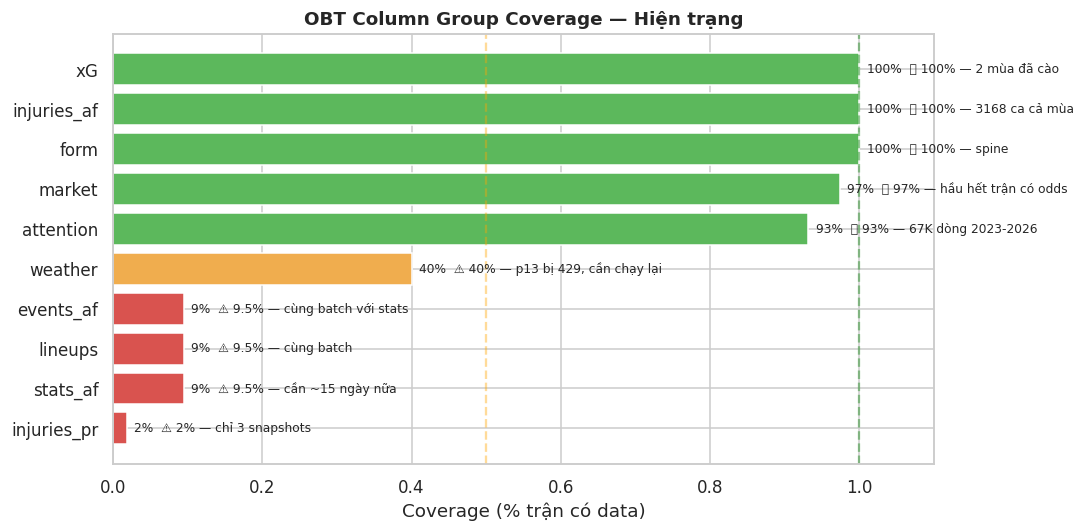

In [38]:
# ── Ước tính độ phủ từng nhóm column trong OBT ────────────────────────────────
# Dựa trên hiện trạng Silver vừa kiểm kê

groups = {
    'form':        ('fd_matches',     760, 760,  '✅ 100% — spine'),
    'market':      ('fd_odds',        760, 740,  '✅ 97% — hầu hết trận có odds'),
    'xG':          ('understat_xg',   760, 760,  '✅ 100% — 2 mùa đã cào'),
    'stats_af':    ('af_match_stats', 760,  72,  '⚠️ 9.5% — cần ~15 ngày nữa'),
    'events_af':   ('af_events',      760,  72,  '⚠️ 9.5% — cùng batch với stats'),
    'lineups':     ('af_lineups',     760,  72,  '⚠️ 9.5% — cùng batch'),
    'injuries_af': ('af_injuries',    760, 760,  '✅ 100% — 3168 ca cả mùa'),
    'weather':     ('fd_weather',     760, 304,  '⚠️ 40% — p13 bị 429, cần chạy lại'),
    'attention':   ('wm_pageviews',   760, 708,  '✅ 93% — 67K dòng 2023-2026'),
    'injuries_pr': ('physioroom',     760,  14,  '⚠️ 2% — chỉ 3 snapshots'),
}

rows = []
for grp, (src, total, covered, note) in groups.items():
    rows.append({'Group': grp, 'Source': src, 'Total': total,
                 'Covered': covered, 'Coverage': covered/total, 'Note': note})

df_cov = pd.DataFrame(rows).sort_values('Coverage', ascending=True)

fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#5cb85c' if v >= 0.8 else '#f0ad4e' if v >= 0.3 else '#d9534f'
          for v in df_cov['Coverage']]
ax.barh(df_cov['Group'], df_cov['Coverage'], color=colors, edgecolor='white')
ax.axvline(1.0, ls='--', color='green', alpha=0.4)
ax.axvline(0.5, ls='--', color='orange', alpha=0.4)
ax.set_xlim(0, 1.1)
ax.set_xlabel('Coverage (% trận có data)')
ax.set_title('OBT Column Group Coverage — Hiện trạng', fontweight='bold')
for i, (_, row) in enumerate(df_cov.iterrows()):
    ax.text(row['Coverage'] + 0.01, i, f'{row["Coverage"]:.0%}  {row["Note"]}',
            va='center', fontsize=8)
plt.tight_layout(); plt.show()


## 11. Action Plan → Build `obt_match_360`

| Bước | Action | Priority |
|------|--------|----------|
| 1 | Chạy lại `p13` (thời tiết) — đã fix 429 handler | 🔴 Cao |
| 2 | Tiếp tục `p24` hàng ngày để cào events/lineups/stats | 🟡 Trung bình |
| 3 | Chạy `build_obt_match.py` join các bảng ✅ Ready | 🔴 Cao |
| 4 | Thêm cột events (goals 1H/2H, red cards) từ af_events | 🟡 Sau khi p24 đủ |
| 5 | Thêm cột lineup (formation, avg_age) từ af_lineups | 🟡 Sau khi p24 đủ |
| 6 | Thêm cột xG per match từ understat_shots (agg) | 🟢 Có thể làm ngay |

**Lệnh chạy build OBT (sau khi viết xong `build_obt_match.py`):**
```bash
cd ~/lab/Lab/football-lake
git pull origin ml
source ~/venv/bin/activate
export PYTHONPATH=/home/azureuser/lab/Lab/football-lake
python notebooks/python/build_obt_match.py
```
